# 03. ResNet18 전이학습

Grayscale crop을 3채널로 변환해 ResNet18 입력 형식에 맞추고 전이학습을 수행합니다.

In [1]:
from pathlib import Path
import random
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms
ROOT = Path('C:/NEU-DET')
CROPS_DIR = ROOT / 'crops'
OUTPUT_FIGURES = ROOT / 'outputs' / 'figures'
OUTPUT_RESULTS = ROOT / 'outputs' / 'results'
OUTPUT_MODELS = ROOT / 'outputs' / 'models'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

device: cuda


In [2]:
IMG_SIZE = 224
BATCH_SIZE = 32
train_tfms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
val_tfms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
train_ds = datasets.ImageFolder(CROPS_DIR / 'train', transform=train_tfms)
val_ds = datasets.ImageFolder(CROPS_DIR / 'validation', transform=val_tfms)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
class_names = train_ds.classes
num_classes = len(class_names)
print(class_names)

['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']


In [3]:
try:
    weights = models.ResNet18_Weights.DEFAULT
    model = models.resnet18(weights=weights)
except AttributeError:
    model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\집 데스크탑/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 29.3MB/s]


In [4]:
def run_one_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = 0.0
    all_preds, all_targets = [], []
    with torch.set_grad_enabled(is_train):
        for images, targets in loader:
            images, targets = images.to(device), targets.to(device)
            outputs = model(images)
            loss = criterion(outputs, targets)
            if is_train:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item() * images.size(0)
            all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
    return total_loss / len(loader.dataset), accuracy_score(all_targets, all_preds)
EPOCHS = 20
best_val_acc = 0.0
best_model_path = OUTPUT_MODELS / 'resnet18_best.pth'
history = []
for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = run_one_epoch(model, val_loader, criterion)
    history.append({'epoch': epoch, 'train_loss': train_loss, 'train_acc': train_acc, 'val_loss': val_loss, 'val_acc': val_acc})
    print(f'Epoch {epoch:02d}/{EPOCHS} | train_loss={train_loss:.4f} train_acc={train_acc:.4f} | val_loss={val_loss:.4f} val_acc={val_acc:.4f}')
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({'model_state_dict': model.state_dict(), 'class_names': class_names, 'img_size': IMG_SIZE}, best_model_path)
        print(f'  saved best model: {best_model_path}')
pd.DataFrame(history).to_csv(OUTPUT_RESULTS / 'resnet18_training_log.csv', index=False, encoding='utf-8-sig')

Epoch 01/20 | train_loss=0.2258 train_acc=0.9265 | val_loss=0.0673 val_acc=0.9848
  saved best model: C:\NEU-DET\outputs\models\resnet18_best.pth
Epoch 02/20 | train_loss=0.0766 train_acc=0.9772 | val_loss=0.0511 val_acc=0.9871
  saved best model: C:\NEU-DET\outputs\models\resnet18_best.pth
Epoch 03/20 | train_loss=0.0448 train_acc=0.9871 | val_loss=0.0417 val_acc=0.9836
Epoch 04/20 | train_loss=0.0293 train_acc=0.9925 | val_loss=0.0381 val_acc=0.9883
  saved best model: C:\NEU-DET\outputs\models\resnet18_best.pth
Epoch 05/20 | train_loss=0.0285 train_acc=0.9916 | val_loss=0.0511 val_acc=0.9848
Epoch 06/20 | train_loss=0.0429 train_acc=0.9892 | val_loss=0.0360 val_acc=0.9906
  saved best model: C:\NEU-DET\outputs\models\resnet18_best.pth
Epoch 07/20 | train_loss=0.0236 train_acc=0.9934 | val_loss=0.0786 val_acc=0.9754
Epoch 08/20 | train_loss=0.0178 train_acc=0.9949 | val_loss=0.0381 val_acc=0.9895
Epoch 09/20 | train_loss=0.0291 train_acc=0.9892 | val_loss=0.1091 val_acc=0.9520
Epoch 

In [5]:
checkpoint = torch.load(OUTPUT_MODELS / 'resnet18_best.pth', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
all_preds, all_targets = [], []
with torch.no_grad():
    for images, targets in val_loader:
        outputs = model(images.to(device))
        all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
        all_targets.extend(targets.numpy())
report_df = pd.DataFrame(classification_report(all_targets, all_preds, target_names=class_names, output_dict=True, zero_division=0)).transpose()
report_df.to_csv(OUTPUT_RESULTS / 'resnet18_classification_report.csv', encoding='utf-8-sig')
report_df

,precision,recall,f1-score,support
crazing,0.993865,1.000000,0.996923,162.000000
inclusion,1.000000,0.981132,0.990476,159.000000
patches,0.984536,0.989637,0.987080,193.000000
pitted_surface,0.977528,1.000000,0.988636,87.000000
rolled-in_scale,1.000000,0.992424,0.996198,132.000000
scratches,1.000000,1.000000,1.000000,121.000000
accuracy,0.992974,0.992974,0.992974,0.992974
macro avg,0.992655,0.993866,0.993219,854.000000
weighted avg,0.993052,0.992974,0.992978,854.000000


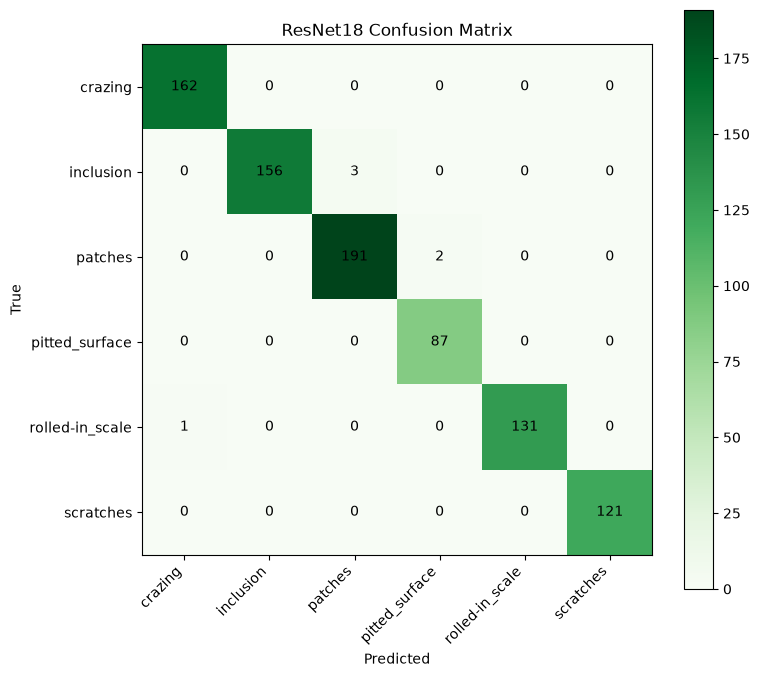

In [6]:
cm = confusion_matrix(all_targets, all_preds)
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap='Greens')
ax.set_xticks(range(num_classes), class_names, rotation=45, ha='right')
ax.set_yticks(range(num_classes), class_names)
ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title('ResNet18 Confusion Matrix')
for i in range(num_classes):
    for j in range(num_classes):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='black')
fig.colorbar(im, ax=ax)
plt.tight_layout(); plt.savefig(OUTPUT_FIGURES / 'resnet18_confusion_matrix.png', dpi=150); plt.show()

In [7]:
def read_accuracy(report_path):
    df = pd.read_csv(report_path, index_col=0)
    return float(df.loc['accuracy', 'precision']) if 'accuracy' in df.index else np.nan
comparison = pd.DataFrame([
    {'model': 'Baseline CNN', 'accuracy': read_accuracy(OUTPUT_RESULTS / 'baseline_classification_report.csv'), 'report_path': str(OUTPUT_RESULTS / 'baseline_classification_report.csv')},
    {'model': 'ResNet18 Transfer', 'accuracy': read_accuracy(OUTPUT_RESULTS / 'resnet18_classification_report.csv'), 'report_path': str(OUTPUT_RESULTS / 'resnet18_classification_report.csv')},
])
comparison.to_csv(OUTPUT_RESULTS / 'model_comparison.csv', index=False, encoding='utf-8-sig')
comparison

,model,accuracy,report_path
0,Baseline CNN,0.893443,C:\NEU-DET\outputs\results\baseline_classifica...
1,ResNet18 Transfer,0.992974,C:\NEU-DET\outputs\results\resnet18_classifica...
